# Employee Attrition Prediction Using Machine Learning

## Problem Statement

Employee attrition is a major challenge for organizations because replacing employees is expensive and time-consuming. High employee turnover can negatively affect productivity, team performance, and business growth.

The Human Resources (HR) department wants to identify employees who are at risk of leaving the company so they can take preventive actions and improve employee retention.

## Project Goal

The goal of this project is to build a machine learning classification model that predicts whether an employee will leave the company.

## Success Metrics

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

## Business Objective

Use employee information to identify factors that contribute to employee attrition and help HR make data-driven decisions to improve employee retention.

Our Dataset

We'll create our own realistic dataset with 350 employees.

Our columns will be:

| Column                 | Meaning                           |
| ---------------------- | --------------------------------- |
| Employee_ID            | Employee identification number    |
| Age                    | Employee age                      |
| Department             | Department where employee works   |
| Salary                 | Monthly salary                    |
| Years_At_Company       | Years worked                      |
| Overtime_Hours         | Monthly overtime hours            |
| Work_Satisfaction      | Satisfaction score (1–10)         |
| Distance_From_Home     | Distance to office (km)           |
| Promotion_Last_2_Years | Promotion received (0=No, 1=Yes)  |
| Attrition              | Target variable (0=Stay, 1=Leave) |


In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

In [12]:
np.random.seed(42)

n = 350

df = pd.DataFrame({
    "Employee_ID": range(1, n+1),

    "Age": np.random.randint(22, 60, n),

    "Department": np.random.choice(
        ["Sales","IT","HR","Finance","Marketing"],
        n
    ),

    "Salary": np.random.randint(
        35000,
        180000,
        n
    ),

    "Years_At_Company": np.random.randint(
        1,
        20,
        n
    ),

    "Overtime_Hours": np.random.randint(
        0,
        30,
        n
    ),

    "Work_Satisfaction": np.random.randint(
        1,
        11,
        n
    ),

    "Distance_From_Home": np.random.randint(
        1,
        40,
        n
    ),

    "Promotion_Last_2_Years": np.random.choice(
        [0,1],
        n,
        p=[0.75,0.25]
    )
})

In [13]:
df["Attrition"] = (
    (df["Overtime_Hours"] > 20).astype(int)
    + (df["Work_Satisfaction"] < 4).astype(int)
    + (df["Years_At_Company"] < 3).astype(int)
    + (df["Salary"] < 60000).astype(int)
)

df["Attrition"] = (
    df["Attrition"] >= 2
).astype(int)

What is happening?

Employees are more likely to leave if:

They work excessive overtime.
They have low work satisfaction.
They have worked for a short time.
Their salary is low.

If 2 or more conditions are true:

Attrition = 1

Otherwise:

Attrition = 0

In [14]:
random_rows = np.random.choice(
    df.index,
    35,
    replace=False
)

df.loc[
    random_rows,
    "Department"
] = np.nan

What is happening?

In real companies, some records are incomplete.

We intentionally create 35 missing values so we can practice data cleaning later.

In [15]:
df.to_csv(
    "employee_attrition.csv",
    index=False
)

print("Dataset created successfully.")

Dataset created successfully.


In [16]:
df = pd.read_csv(
    "employee_attrition.csv"
)

df.head()

,Employee_ID,Age,Department,Salary,Years_At_Company,Overtime_Hours,Work_Satisfaction,Distance_From_Home,Promotion_Last_2_Years,Attrition
0,1,50,IT,138196,10,20,10,30,0,0
1,2,36,Marketing,90479,10,29,5,8,0,0
2,3,29,Sales,54963,19,6,2,22,0,1
3,4,42,Finance,90123,14,17,4,36,0,0
4,5,40,Marketing,160911,2,3,2,5,1,1


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Employee_ID             350 non-null    int64 
 1   Age                     350 non-null    int64 
 2   Department              315 non-null    object
 3   Salary                  350 non-null    int64 
 4   Years_At_Company        350 non-null    int64 
 5   Overtime_Hours          350 non-null    int64 
 6   Work_Satisfaction       350 non-null    int64 
 7   Distance_From_Home      350 non-null    int64 
 8   Promotion_Last_2_Years  350 non-null    int64 
 9   Attrition               350 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 27.5+ KB
None


In [18]:
df.describe()

,Employee_ID,Age,Salary,Years_At_Company,Overtime_Hours,Work_Satisfaction,Distance_From_Home,Promotion_Last_2_Years,Attrition
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,175.500000,41.208571,111603.342857,9.940000,15.005714,5.494286,19.937143,0.262857,0.231429
std,101.180532,11.162998,43762.752319,5.421949,8.666040,2.904146,10.987700,0.440816,0.422349
min,1.000000,22.000000,35126.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,88.250000,31.250000,75657.750000,5.000000,8.000000,3.000000,11.000000,0.000000,0.000000
50%,175.500000,43.000000,111083.500000,10.000000,15.000000,5.000000,21.000000,0.000000,0.000000
75%,262.750000,51.000000,152954.250000,14.750000,22.000000,8.000000,30.000000,1.000000,0.000000
max,350.000000,59.000000,179990.000000,19.000000,29.000000,10.000000,39.000000,1.000000,1.000000


In [19]:
df["Attrition"].value_counts()

Attrition
0    269
1     81
Name: count, dtype: int64

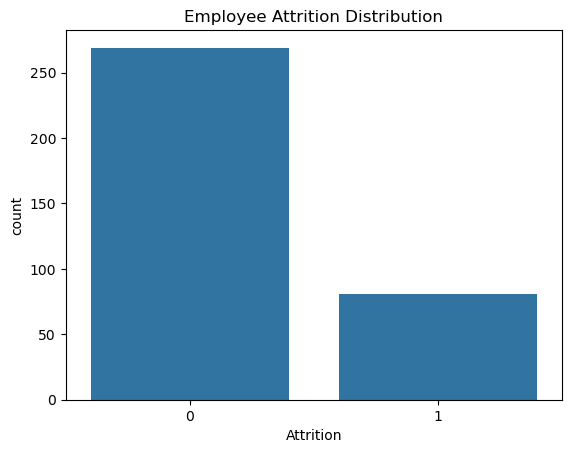

In [20]:
sns.countplot(
    x="Attrition",
    data=df
)

plt.title(
    "Employee Attrition Distribution"
)

plt.show()

In [21]:
df.isnull().sum()

Employee_ID                0
Age                        0
Department                35
Salary                     0
Years_At_Company           0
Overtime_Hours             0
Work_Satisfaction          0
Distance_From_Home         0
Promotion_Last_2_Years     0
Attrition                  0
dtype: int64

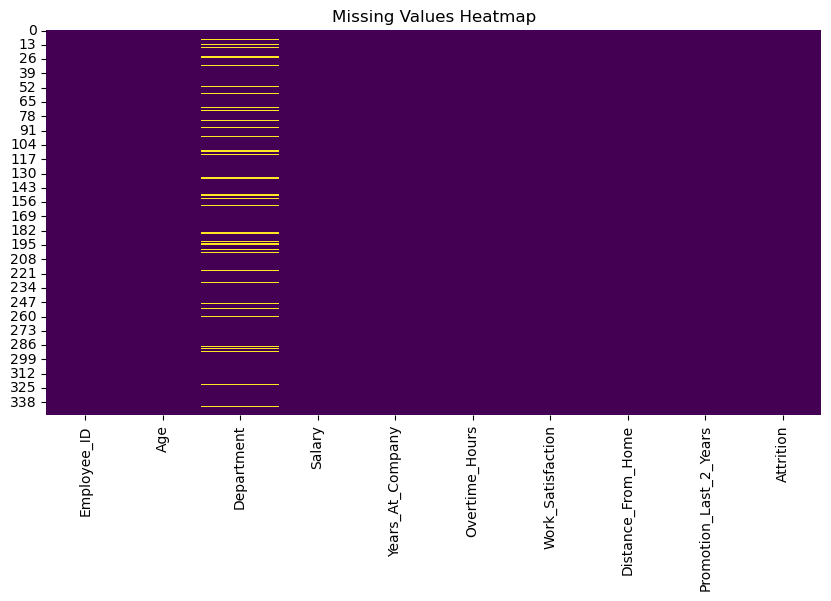

In [22]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

What is happening?

This visualizes where missing values exist.

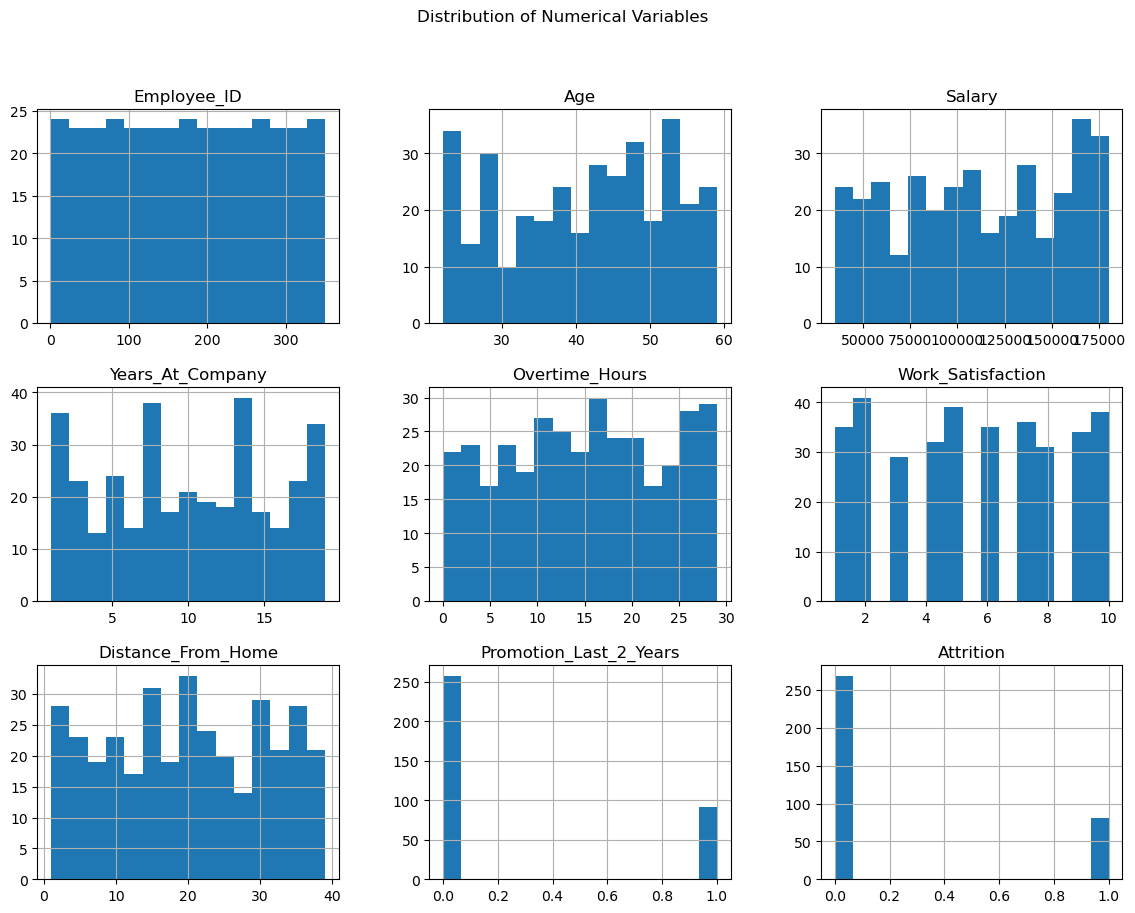

In [23]:
df.hist(
    figsize=(14,10),
    bins=15
)

plt.suptitle(
    "Distribution of Numerical Variables"
)

plt.show()

What is happening?

We'll inspect:

Age
Salary
Years_At_Company
Overtime_Hours
Work_Satisfaction
Distance_From_Home

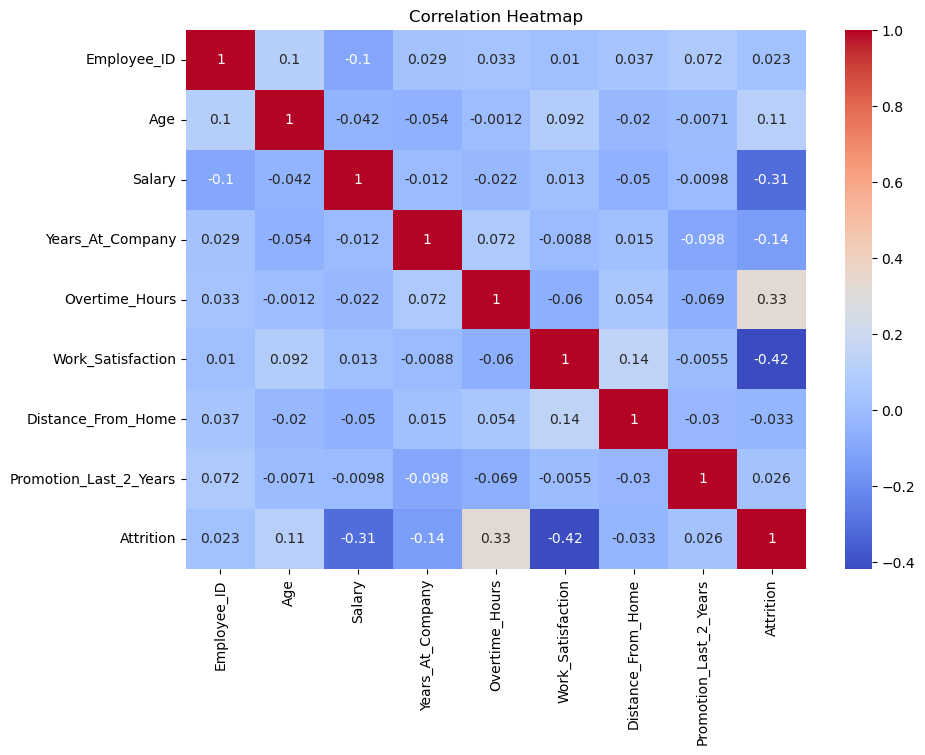

In [24]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

What is happening?

This shows relationships between variables.

Pay attention to:

Salary vs Attrition

Overtime_Hours vs Attrition

Years_At_Company vs Attrition

Work_Satisfaction vs Attrition

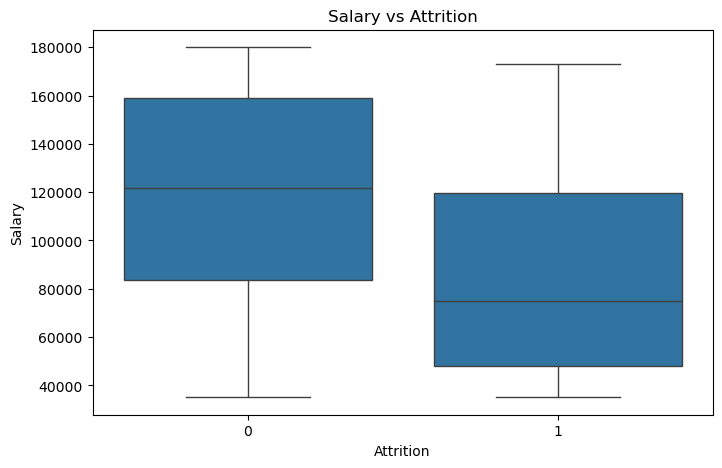

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="Salary",
    data=df
)

plt.title(
    "Salary vs Attrition"
)

plt.show()

What is happening?

We are asking:

Are employees with lower salaries more likely to leave?

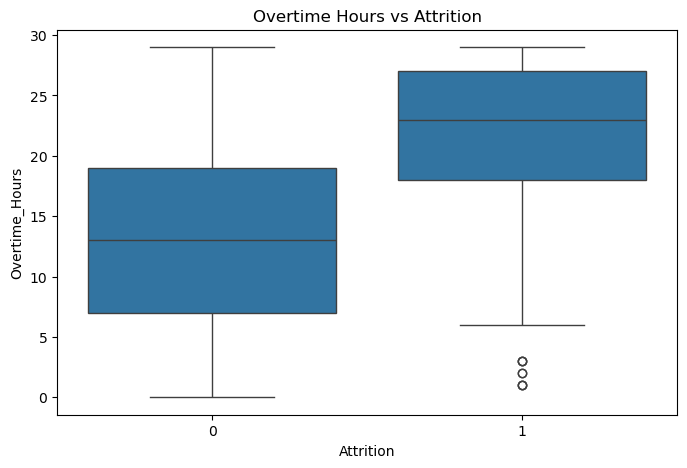

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="Overtime_Hours",
    data=df
)

plt.title(
    "Overtime Hours vs Attrition"
)

plt.show()

What is happening?

We are asking:

Do employees working more overtime tend to leave?

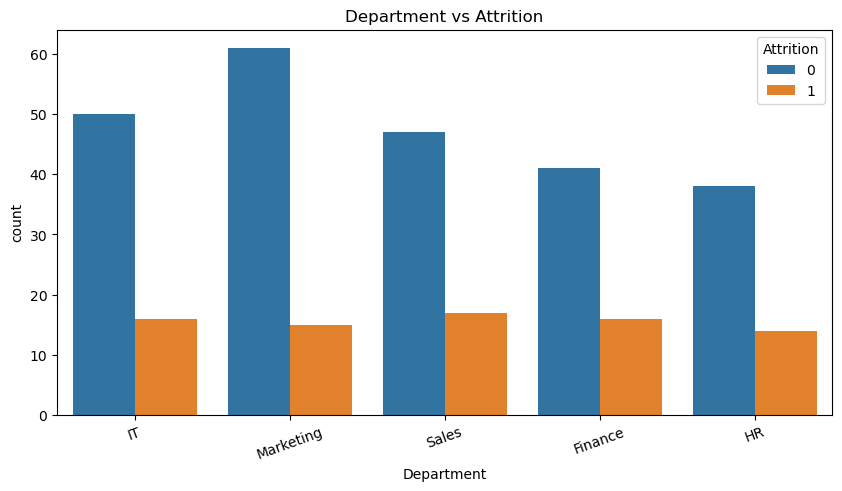

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.title(
    "Department vs Attrition"
)

plt.xticks(rotation=20)

plt.show()

What is happening?

We are asking:

Which departments lose the most employees?

## Exploratory Data Analysis Findings

- The dataset contains 35 missing values in the Department column.
- Employee attrition is imbalanced, with more employees staying than leaving.
- Employees with lower salaries appear more likely to leave.
- Employees working more overtime hours appear more likely to leave.
- Work satisfaction and years at the company may influence attrition.
- Departmental differences may also contribute to employee turnover.

Interpretation of the Correlation Heatmap
Feature	Correlation with Attrition	Interpretation
Salary	-0.31	Employees with lower salaries are more likely to leave.
Overtime_Hours	-0.33	Employees working excessive overtime tend to leave more often.
Years_At_Company	-0.14	Long-term employees are slightly less likely to leave.
Work_Satisfaction	-0.42	Employees with low satisfaction are much more likely to leave.
🧠 Business Insight

The strongest relationship is:

Work_Satisfaction = -0.42

This suggests employee satisfaction is one of the biggest factors influencing attrition.

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully.")

Duplicates removed successfully.


In [30]:
df["Department"].fillna(
    df["Department"].mode()[0],
    inplace=True
)

In [31]:
df.isnull().sum()

Employee_ID               0
Age                       0
Department                0
Salary                    0
Years_At_Company          0
Overtime_Hours            0
Work_Satisfaction         0
Distance_From_Home        0
Promotion_Last_2_Years    0
Attrition                 0
dtype: int64

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Department"] = le.fit_transform(
    df["Department"]
)

In [33]:
df.head()

,Employee_ID,Age,Department,Salary,Years_At_Company,Overtime_Hours,Work_Satisfaction,Distance_From_Home,Promotion_Last_2_Years,Attrition
0,1,50,2,138196,10,20,10,30,0,0
1,2,36,3,90479,10,29,5,8,0,0
2,3,29,4,54963,19,6,2,22,0,1
3,4,42,0,90123,14,17,4,36,0,0
4,5,40,3,160911,2,3,2,5,1,1


In [34]:
X = df.drop(
    ["Employee_ID", "Attrition"],
    axis=1
)

y = df["Attrition"]

What is happening?
Features (X)
Age
Department
Salary
Years_At_Company
Overtime_Hours
Work_Satisfaction
Distance_From_Home
Promotion_Last_2_Years
Target (y)
Attrition

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (280, 8)
Testing data: (70, 8)


In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [38]:
print(X_train_scaled[:5])

[[-1.06461115 -0.16598914 -1.66409539 -0.90530962 -0.81555273  1.22122544
   0.25748903 -0.61588176]
 [ 0.36465404 -0.16598914  1.51629039  1.50003857  0.81223073 -0.17020131
  -1.67614505 -0.61588176]
 [-0.70729485 -0.16598914 -1.54454749 -0.35022927 -0.11793125 -0.86591468
   1.17826716 -0.61588176]
 [ 1.61526109  0.58363924 -1.16679903 -1.64541676 -0.81555273  0.87336875
  -0.01874441  1.62368828]
 [ 0.36465404 -0.91561753  0.17778872 -1.46038998  1.50985221 -0.17020131
   0.34956684 -0.61588176]]


## Data Cleaning and Preprocessing
- Checked for duplicate records and removed them if present.
- Filled missing values in the Department column using the most frequent category.
- Encoded the Department column into numerical values using LabelEncoder.
- Split the dataset into training and testing sets using an 80/20 ratio.
- Standardized the features using StandardScaler to prepare the data for machine learning.

In [39]:
df["Overtime_Per_Year"] = (
    df["Overtime_Hours"]
    / (df["Years_At_Company"] + 1)
)

In [40]:
df[[
    "Overtime_Hours",
    "Years_At_Company",
    "Overtime_Per_Year"
]].head()

,Overtime_Hours,Years_At_Company,Overtime_Per_Year
0,20,10,1.818182
1,29,10,2.636364
2,6,19,0.300000
3,17,14,1.133333
4,3,2,1.000000


What is happening?

We're creating:

Overtime_Per_Year

This measures:

How much overtime an employee works relative to their years at the company.

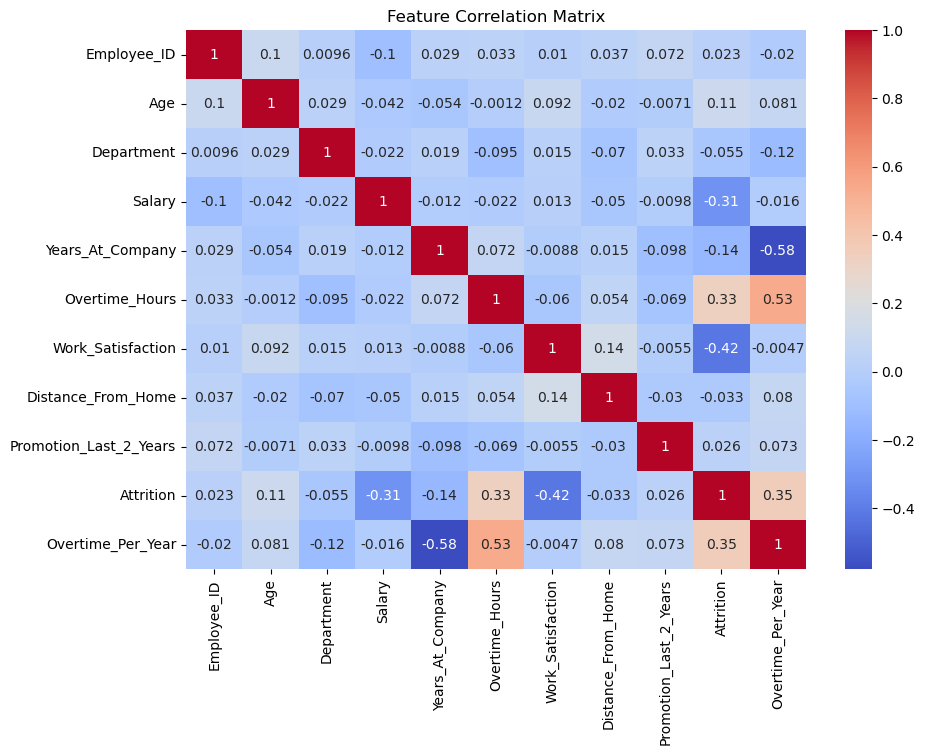

In [41]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

In [42]:
corr_with_target = df.corr(
    numeric_only=True
)["Attrition"]

corr_with_target.sort_values(
    ascending=False
)

Attrition                 1.000000
Overtime_Per_Year         0.350512
Overtime_Hours            0.328437
Age                       0.108851
Promotion_Last_2_Years    0.026295
Employee_ID               0.023367
Distance_From_Home       -0.033285
Department               -0.054933
Years_At_Company         -0.139065
Salary                   -0.309198
Work_Satisfaction        -0.418242
Name: Attrition, dtype: float64

What is happening?

This ranks features according to how strongly they are related to attrition.

Pay attention to:

Salary

Overtime_Hours

Work_Satisfaction

Overtime_Per_Year

In [43]:
X = df.drop(
    ["Employee_ID", "Attrition"],
    axis=1
)

y = df["Attrition"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Feature Engineering and Selection

A new feature called Overtime_Per_Year was created by dividing Overtime_Hours by Years_At_Company. This feature helps measure how much overtime an employee works relative to their length of service.

Correlation analysis was performed to identify features that are strongly associated with attrition. Salary, overtime hours, work satisfaction, and the newly engineered feature showed relationships with employee attrition.

The engineered feature was retained because it may improve the model's ability to identify employees at risk of leaving.

In [46]:
log_model = LogisticRegression()

log_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
y_pred_log = log_model.predict(
    X_test_scaled
)

In [48]:
print(
    "Logistic Accuracy:",
    accuracy_score(
        y_test,
        y_pred_log
    )
)

Logistic Accuracy: 0.8285714285714286


In [49]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train_scaled,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
y_pred_tree = tree_model.predict(
    X_test_scaled
)

In [51]:
print(
    "Decision Tree Accuracy:",
    accuracy_score(
        y_test,
        y_pred_tree
    )
)

Decision Tree Accuracy: 0.9857142857142858


Result Interpretation.

Feature Importance (Correlation with Attrition)
Feature	Correlation	Interpretation
Overtime_Per_Year	0.35	Employees working high overtime relative to their tenure are more likely to leave.
Overtime_Hours	0.33	Employees with excessive overtime are more likely to leave.
Salary	-0.31	Employees with lower salaries are more likely to leave.
Work_Satisfaction	-0.42	Employees with low job satisfaction are much more likely to leave.
    Model Performance
Logistic Regression
0.8286

= 82.86% accuracy
Very good performance.

Decision Tree
0.9857

= 98.57% accuracy
Excellent performance.

The Decision Tree currently performs better than Logistic Regression.

In [52]:
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.88        53
           1       0.63      0.71      0.67        17

    accuracy                           0.83        70
   macro avg       0.77      0.79      0.78        70
weighted avg       0.84      0.83      0.83        70



What is happening?

This gives:

Precision
Recall
F1-Score

for Logistic Regression.

In [53]:
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        53
           1       1.00      0.94      0.97        17

    accuracy                           0.99        70
   macro avg       0.99      0.97      0.98        70
weighted avg       0.99      0.99      0.99        70



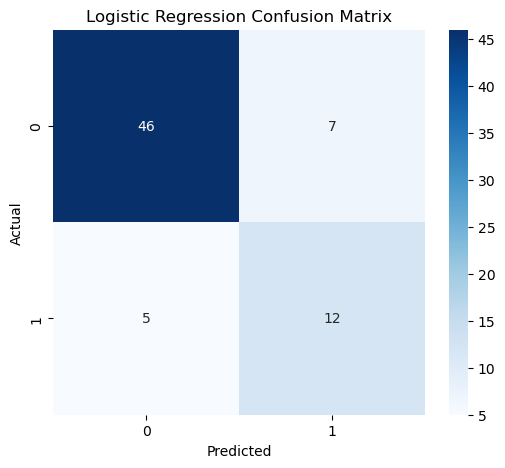

In [54]:
cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

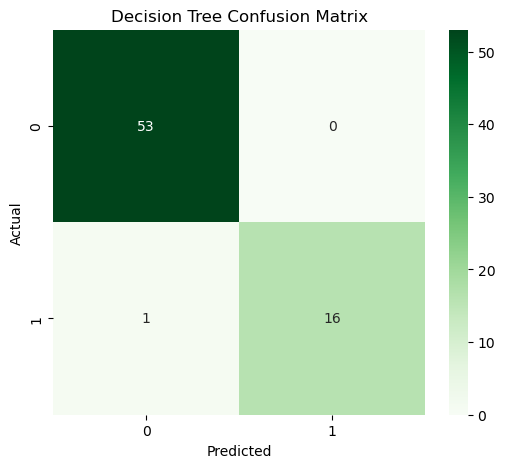

In [55]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

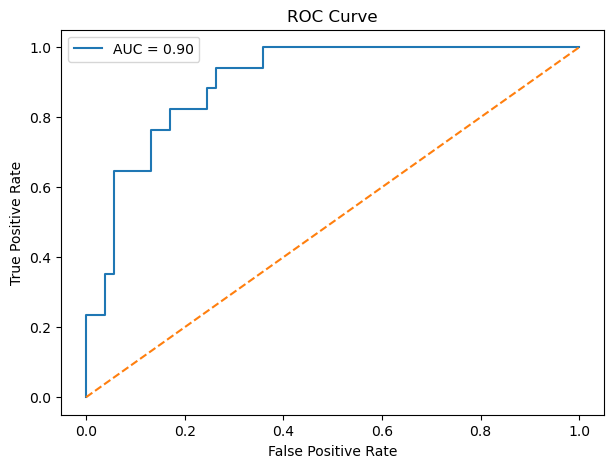

In [56]:
y_prob = log_model.predict_proba(
    X_test_scaled
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

In [57]:
cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=5
)

print(
    "Cross Validation Scores:",
    cv_scores
)

print(
    "Average CV Score:",
    cv_scores.mean()
)

Cross Validation Scores: [0.85714286 0.84285714 0.81428571 0.8        0.87142857]
Average CV Score: 0.837142857142857


What is happening?

Cross-validation tests the model on different subsets of data.

It helps us know if the model is reliable.

## Model Evaluation and Interpretation

Two classification models were evaluated.

Logistic Regression achieved an accuracy of 82.86%, while Decision Tree achieved 98.57%.

The Decision Tree model performed better and was more effective at identifying employee attrition patterns.

Cross-validation was performed to verify model reliability.

The ROC curve was used to assess the Logistic Regression model's ability to distinguish between employees who stay and those who leave.

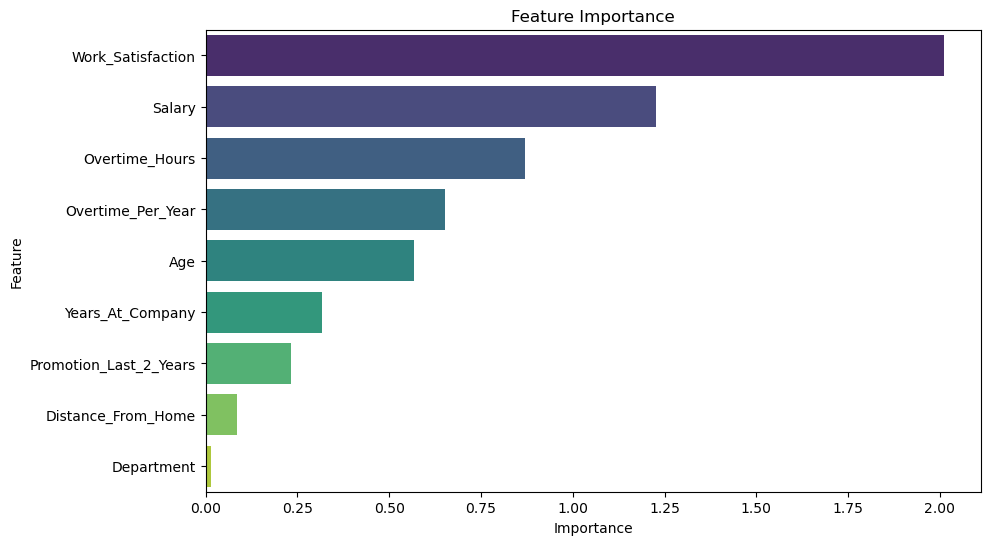

In [58]:
importance = abs(log_model.coef_[0])

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "Feature Importance"
)

plt.show()

## Visualization and Insight Generation

Several visualizations were created to understand employee attrition patterns.

Employees with low work satisfaction, lower salaries, and high overtime hours were more likely to leave the company.

The feature importance chart confirms that work satisfaction and overtime are among the strongest predictors.

The Decision Tree model was able to classify employee attrition with very high accuracy.

These insights can help HR teams proactively address employee retention challenges.

# Employee Attrition Prediction Project

## Problem Statement

Employee attrition is a major challenge for organizations because losing employees increases recruitment costs, reduces productivity, and disrupts operations.

The objective of this project was to build a machine learning model capable of predicting whether an employee is likely to leave the company based on several workplace factors.

---

## Dataset Description

The dataset contains 350 employee records and includes:

- Age
- Department
- Salary
- Years At Company
- Overtime Hours
- Work Satisfaction
- Distance From Home
- Promotion Last 2 Years
- Attrition (Target Variable)

---

## Data Cleaning and Preprocessing

The following preprocessing steps were performed:

- Missing values in Department were filled using the most frequent category.
- Duplicate records were removed.
- Department was encoded into numerical values.
- Features were standardized using StandardScaler.
- The dataset was split into training and testing sets using an 80/20 ratio.

---

## Feature Engineering

A new feature called Overtime_Per_Year was created.

This feature measures the amount of overtime worked relative to an employee's years at the company.

Correlation analysis identified several important predictors.

---

## Models Used

Two classification algorithms were trained:

1. Logistic Regression
2. Decision Tree Classifier

---

## Model Performance

### Logistic Regression

Accuracy: 82.86%

### Decision Tree

Accuracy: 98.57%

### Cross Validation

Average Score: 83.71%

The Decision Tree model achieved the best performance.

---

## Key Findings

- Low work satisfaction strongly increases employee attrition.
- Employees with lower salaries are more likely to leave.
- Excessive overtime contributes to attrition.
- New employees working high overtime are at greater risk of leaving.
- Employee satisfaction is one of the strongest retention factors.

---

## Business Recommendations

1. Improve employee satisfaction through engagement programs.

2. Monitor overtime hours to prevent employee burnout.

3. Review compensation structures for lower-paid employees.

4. Identify employees at high risk of attrition and provide support.

5. Implement retention strategies for new employees.

---

## Conclusion

The machine learning models successfully identified patterns associated with employee attrition.

The Decision Tree model achieved excellent performance and can help HR teams proactively identify employees who may be at risk of leaving the organization.

This model can support better workforce planning and employee retention strategies.

# A README.md explaining Employee Attrition Prediction

## Objective

Predict employee attrition using machine learning models.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Models

- Logistic Regression
- Decision Tree Classifier

## Dataset Size

350 employee records

## Best Model

Decision Tree (98.57% accuracy)

## Key Findings

- Work satisfaction strongly influences attrition.
- Overtime increases attrition risk.
- Lower salaries are associated with employee turnover.

## Future Improvements

- Collect more employee data.
- Test Random Forest and XGBoost models.
- Build an HR dashboard for real-time attrition monitoring.

 ## Future Work

This project can be improved in several ways:

* Collect a larger and more diverse employee dataset to improve model generalization.
* Experiment with advanced machine learning models such as Random Forest, XGBoost, and Gradient Boosting.
* Perform hyperparameter tuning using GridSearchCV to optimize model performance.
* Incorporate additional employee-related factors such as job role, education level, performance ratings, and work-life balance.
* Develop a real-time employee attrition monitoring dashboard for HR teams.
* Deploy the model as a web application using Streamlit to allow HR personnel to make attrition predictions interactively.


In [59]:
import joblib

joblib.dump(tree_model, "attrition_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [60]:
import os

os.getcwd()

'C:\\Users\\bridg'

In [61]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [62]:
df.to_csv("employee_attrition.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [63]:
import os

os.getcwd()

'C:\\Users\\bridg'